In [1]:
import pandas as pd
import tensorflow as tf
import os
from working_data import clean_cols, clean_non_minute_rows, alt_label_df as label_df, normalize_by_window, split_df, add_bollinger_bands
from data_builder_trans import create_dataset_generator, get_total_rows
from model_builder_trans import build_transformer_model, combined_loss
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

2024-10-17 14:16:27.529295: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-17 14:16:27.641136: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-17 14:16:28.601635: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2024-10-17 14:16:29.650956: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-10-17 14:16:29.771865: 

In [2]:
NORMALIZING_WINDOW_SIZE = 180
LABELING_WINDOW_SIZE = 20
POSITIVE_SLOPE = 0.3
LABEL_CUR_CANDLE_MULTIPLIER = 0
LABEL_MEAN_MULTIPLIER = 8
BATCH_SIZE = 32
NUM_TRANSFORMER_TOKENS = 124
D_MODEL = 64
FF_DIM = D_MODEL*2
NUM_HEADS = D_MODEL//8
NUM_TRANSFORMER_LAYERS = 2

In [3]:
source_csv = "data/GBPUSD/minutes.csv"
working_path = "working"

In [4]:
df = pd.read_csv(source_csv)
df = clean_non_minute_rows(df)
df = clean_cols(df)
break_point = len(df) - len(df)//20
df = df[break_point:]
df = normalize_by_window(
    df, 
    window_size=NORMALIZING_WINDOW_SIZE, 
    normalizing_cols=[
        'open',
        'high',
        'low',
        'close'
    ])
print("labeling")
df = label_df(df, window_size=LABELING_WINDOW_SIZE, mean_multiplier=LABEL_MEAN_MULTIPLIER, cur_candle_multiplier=LABEL_CUR_CANDLE_MULTIPLIER)
print(df['target'].value_counts())
split_df(df=df, dump_path=working_path)

labeling
target
0    426393
1     22541
Name: count, dtype: int64


In [5]:
input_shape = (NUM_TRANSFORMER_TOKENS, 4)  #4 features per token
model = build_transformer_model(input_shape, d_model=D_MODEL, ff_dim=FF_DIM, num_heads=NUM_HEADS, num_layers=NUM_TRANSFORMER_LAYERS, training=True)
auc =  tf.keras.metrics.AUC()
auc.reset_state()
prec = tf.keras.metrics.Precision()
prec.reset_state()
model.compile(optimizer='adam', 
              loss=combined_loss, 
              metrics=['accuracy',auc, prec])



In [6]:
train_file = os.path.join(working_path, 'train.csv')
val_file = os.path.join(working_path, 'val.csv')
test_file = os.path.join(working_path, 'test.csv')

train_dataset= create_dataset_generator(train_file, batch_size=BATCH_SIZE, num_tokens=NUM_TRANSFORMER_TOKENS, smote=True, shuffle=True, repeat=True).prefetch(tf.data.AUTOTUNE)
val_dataset = create_dataset_generator(val_file, batch_size=BATCH_SIZE, num_tokens=NUM_TRANSFORMER_TOKENS, repeat=True).prefetch(tf.data.AUTOTUNE)
test_dataset = create_dataset_generator(test_file, batch_size=BATCH_SIZE, num_tokens=NUM_TRANSFORMER_TOKENS).prefetch(tf.data.AUTOTUNE)

train_steps_per_epoch = get_total_rows(train_file, smote=True, num_tokens=NUM_TRANSFORMER_TOKENS)//BATCH_SIZE
val_steps_per_epoch = get_total_rows(val_file, num_tokens=NUM_TRANSFORMER_TOKENS)//BATCH_SIZE
test_steps_per_epoch = get_total_rows(test_file, num_tokens=NUM_TRANSFORMER_TOKENS)//BATCH_SIZE


In [7]:
for data in train_dataset.take(1):
    inputs, labels = data
    print("Inputs:", inputs.numpy())
    print("Labels:", labels.numpy())

Inputs: [[[0.8169935  0.85620916 0.77124184 0.7777778 ]
  [0.8235294  0.90849674 0.7777778  0.8366013 ]
  [0.84313726 0.8888889  0.7647059  0.7647059 ]
  ...
  [0.87083334 0.9625     0.84166664 0.8875    ]
  [0.87916666 0.9125     0.8541667  0.90833336]
  [0.8908297  0.9694323  0.8689956  0.94323146]]

 [[0.7522727  0.7909091  0.7477273  0.7886364 ]
  [0.78636366 0.7909091  0.77272725 0.7772727 ]
  [0.7818182  0.8        0.7818182  0.7977273 ]
  ...
  [0.6706161  0.7085308  0.66824645 0.70379144]
  [0.70379144 0.7132701  0.7014218  0.7085308 ]
  [0.6871795  0.6974359  0.6846154  0.6871795 ]]

 [[0.08355092 0.11488251 0.04960835 0.05483029]
  [0.05221932 0.07832898 0.02872063 0.07571802]
  [0.08355092 0.08355092 0.03916449 0.07832898]
  ...
  [0.02941176 0.04901961 0.00980392 0.00980392]
  [0.06060606 0.07925408 0.         0.        ]
  [0.02721088 0.12698413 0.         0.12471655]]

 ...

 [[0.24615385 0.24615385 0.24615385 0.24615385]
  [0.24615385 0.26153848 0.16923077 0.16923077]
  

2024-10-17 14:18:06.551405: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
early_stopping = EarlyStopping(monitor='val_precision_1', 
                               patience=5, # Stops if there's no improvement in precision for 5 epochs
                               mode='max', 
                               verbose=1)

model_checkpoint = ModelCheckpoint('best_trans_model.keras', 
                                   monitor='val_precision_1', 
                                   save_best_only=True, 
                                   mode='max', 
                                   verbose=1)

# Train the model using the train and validation datasets
history = model.fit(
    train_dataset,
    epochs=20,
    steps_per_epoch = train_steps_per_epoch,
    validation_data=val_dataset,
    validation_steps=val_steps_per_epoch,
    callbacks=[early_stopping, model_checkpoint]
)


# Load the best model after training
model.load_weights('best_trans_model.keras')

Epoch 1/20


I0000 00:00:1729167491.431436  278904 service.cc:145] XLA service 0x7eff0000a4a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1729167491.431632  278904 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
2024-10-17 14:18:11.540467: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-10-17 14:18:11.997392: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1729167495.589565  279210 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_99', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1729167496.744611  279212 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_99', 8 bytes spill stores, 8 bytes spill loads

I000

    7/18663 ━━━━━━━━━━━━━━━━━━━━ 6:32 21ms/step - accuracy: 0.4607 - auc: 0.4137 - loss: 0.9968 - precision_1: 0.4624  

I0000 00:00:1729167505.458336  278904 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


18662/18663 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6736 - auc: 0.7364 - loss: 0.7842 - precision_1: 0.6472
Epoch 1: val_precision_1 improved from -inf to 0.11244, saving model to best_trans_model.keras
18663/18663 ━━━━━━━━━━━━━━━━━━━━ 435s 22ms/step - accuracy: 0.6737 - auc: 0.7364 - loss: 0.7842 - precision_1: 0.6472 - val_accuracy: 0.6617 - val_auc: 0.8142 - val_loss: 0.9141 - val_precision_1: 0.1124
Epoch 2/20
18662/18663 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7552 - auc: 0.8240 - loss: 0.6665 - precision_1: 0.7101
Epoch 2: val_precision_1 improved from 0.11244 to 0.11537, saving model to best_trans_model.keras
18663/18663 ━━━━━━━━━━━━━━━━━━━━ 433s 23ms/step - accuracy: 0.7552 - auc: 0.8240 - loss: 0.6665 - precision_1: 0.7101 - val_accuracy: 0.6714 - val_auc: 0.8233 - val_loss: 0.9161 - val_precision_1: 0.1154
Epoch 3/20
18661/18663 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7632 - auc: 0.8331 - loss: 0.6496 - precision_1: 0.7154
Epoch 3: val_precision_1 did 

In [ ]:
predictions = model.predict(test_dataset)

# Convert probabilities to binary class (0 or 1) using a threshold of 0.5
predicted_class = (predictions > 0.5).astype(int)


2102/2102 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step


2024-10-17 12:44:15.187846: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
y_true = []

for input_tensor, target_tensor in test_dataset:
    y_true.extend(target_tensor.numpy()) 

2024-10-17 12:44:54.976155: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
len(predicted_class), len(y_true)

(67264, 67264)

Confusion Matrix:
 [[44462 19262]
 [  671  2869]]


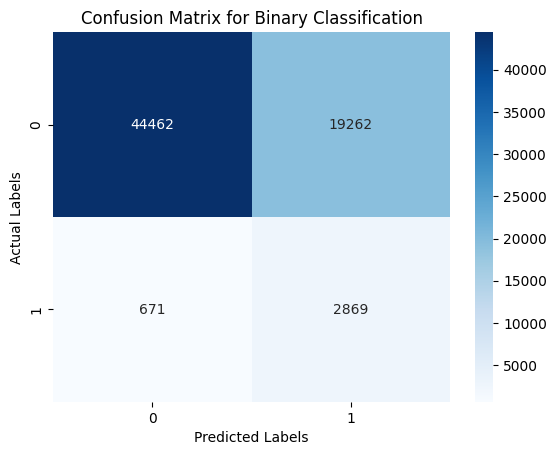

In [ ]:
conf_matrix = confusion_matrix(y_true, predicted_class)

print("Confusion Matrix:\n", conf_matrix)

# Optionally: Visualize the confusion matrix using a heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix for Binary Classification')
plt.show()

In [ ]:
model.evaluate(test_dataset)

2102/2102 ━━━━━━━━━━━━━━━━━━━━ 47s 23ms/step - accuracy: 0.7125 - auc: 0.8335 - loss: 0.8670 - precision_1: 0.1415


2024-10-17 12:45:42.681597: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2024-10-17 12:45:42.681649: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_2]]
2024-10-17 12:45:42.681709: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 7087641831313091086
2024-10-17 12:45:42.681732: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 16266299805499932158
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, trac

[0.88107830286026, 0.7036601901054382, 0.8285989165306091, 0.12963716685771942]